### Stage2 -  агент (vLLM + tools + validation)

Ноутбук выполняет запуск локального vLLM, инициализацию агента с инструментами, валидацию и визуализацию потока.

1. Cell 1 — установка зависимостей.
2. Cell 2 — запуск vLLM API и ожидание готовности `/models`.
3. Cell 3 — объявление инструментов и создание агента.
4. Cell 4 — runtime-логика (парсинг tool-calls, pre-check, logging).
5. Cell 5 — валидация на датасете.
6. Cell 6 — smoke-тесты.
7. Cell 7 — граф исполнения.

### Основные параметры
В Cell 2:
- `MODEL_ID`
- `PORT`
- `STARTUP_TIMEOUT_SEC`
- `POLL_INTERVAL_SEC`
- `VLLM_TOOL_CALL_PARSER` (по умолчанию `qwen3_xml`)

При использовании внешнего сервера `BASE_URL` задается в Cell 3.

### Датасет
Путь для датасета: `/content/validation_dataset_stage2.jsonl`.



In [1]:
# 1) Установка зависимостей
import sys

!{sys.executable} -m pip install -U -q vllm langgraph langchain-openai langchain-core pydantic requests psutil nest_asyncio networkx matplotlib graphviz

import nest_asyncio
nest_asyncio.apply()

print("[ИНФО] Зависимости установлены.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 152.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 136.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.

In [2]:
# 2) Start vLLM backend server (downloads + loads the Hugging Face model)
# Model: https://huggingface.co/Qwen/Qwen3-30B-A3B-Instruct-2507-FP8

import os
import sys
import time
import subprocess
import requests
import psutil
import gc

# Protobuf compatibility
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

MODEL_ID = "Qwen/Qwen3-30B-A3B-Instruct-2507-FP8"
PORT = 8000
BASE_URL = f"http://localhost:{PORT}/v1"

# Startup wait settings
STARTUP_TIMEOUT_SEC = int(os.environ.get("VLLM_STARTUP_TIMEOUT_SEC", "900"))
POLL_INTERVAL_SEC = float(os.environ.get("VLLM_POLL_INTERVAL_SEC", "5"))

# Hugging Face token
# os.environ["HF_TOKEN"] = "<your_hf_token>"

print("[INFO] Cleaning up old server processes...")
for proc in psutil.process_iter(["pid", "name"]):
    try:
        for conn in proc.connections(kind="inet"):
            if conn.laddr and conn.laddr.port == PORT:
                print(f"[INFO] Killing PID={proc.pid} name={proc.name()} on port {PORT}")
                proc.kill()
    except (psutil.NoSuchProcess, psutil.AccessDenied, psutil.ZombieProcess):
        pass

# CUDA cache cleanup
try:
    import torch
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("[INFO] CUDA cache cleared.")
except Exception:
    pass

time.sleep(1)

# Tool call parser
raw_parser = os.environ.get("VLLM_TOOL_CALL_PARSER", "qwen3_xml").strip()
if raw_parser.lower() == "qwen":
    print("[WARN] VLLM_TOOL_CALL_PARSER='qwen' is invalid for vLLM 0.15.1. Mapping to 'qwen3_xml'.")
    raw_parser = "qwen3_xml"

tool_call_parser = raw_parser

cmd = [
    sys.executable,
    "-m",
    "vllm.entrypoints.openai.api_server",
    "--model",
    MODEL_ID,
    "--served-model-name",
    MODEL_ID,
    "--trust-remote-code",
    "--dtype",
    "auto",
    "--max-model-len",
    "8192",
    "--gpu-memory-utilization",
    "0.90",
    "--host",
    "0.0.0.0",
    "--port",
    str(PORT),
    "--enable-auto-tool-choice",
    "--tool-call-parser",
    tool_call_parser,
]

print("[INFO] Starting vLLM server...")
print("[INFO] Tool-call parser:", tool_call_parser)
print("[INFO] Startup timeout (sec):", STARTUP_TIMEOUT_SEC)
print("[INFO] Poll interval (sec):", POLL_INTERVAL_SEC)
print("[INFO] Command:", " ".join(cmd))

log_path = "vllm_server.log"
log_file = open(log_path, "w", encoding="utf-8")
process = subprocess.Popen(cmd, stdout=log_file, stderr=subprocess.STDOUT)

print(f"[INFO] Server PID={process.pid}")
print("[INFO] Waiting for /models to be available (can take a few minutes on first load)...")

start = time.time()
while True:
    if process.poll() is not None:
        print("[ERROR] vLLM process exited early.")
        print("[ERROR] Check vllm_server.log for details.")
        break

    try:
        r = requests.get(f"{BASE_URL}/models", timeout=5)
        if r.ok:
            print("[INFO] vLLM is online.")
            print("[INFO] BASE_URL:", BASE_URL)
            print("[INFO] /models (short):", r.text[:300])
            break
    except requests.exceptions.RequestException:
        pass

    if time.time() - start > STARTUP_TIMEOUT_SEC:
        print("[ERROR] Timeout waiting for vLLM server.")
        print("[ERROR] Check vllm_server.log")
        process.kill()
        break

    time.sleep(POLL_INTERVAL_SEC)
    print(".", end="", flush=True)

[INFO] Cleaning up old server processes...
[INFO] CUDA cache cleared.
[INFO] Starting vLLM server...
[INFO] Tool-call parser: qwen3_xml
[INFO] Startup timeout (sec): 900
[INFO] Poll interval (sec): 5.0
[INFO] Command: /usr/bin/python3 -m vllm.entrypoints.openai.api_server --model Qwen/Qwen3-30B-A3B-Instruct-2507-FP8 --served-model-name Qwen/Qwen3-30B-A3B-Instruct-2507-FP8 --trust-remote-code --dtype auto --max-model-len 8192 --gpu-memory-utilization 0.90 --host 0.0.0.0 --port 8000 --enable-auto-tool-choice --tool-call-parser qwen3_xml
[INFO] Server PID=1911
[INFO] Waiting for /models to be available (can take a few minutes on first load)...
.........................................................[INFO] vLLM is online.
[INFO] BASE_URL: http://localhost:8000/v1
[INFO] /models (short): {"object":"list","data":[{"id":"Qwen/Qwen3-30B-A3B-Instruct-2507-FP8","object":"model","created":1771320169,"owned_by":"vllm","root":"Qwen/Qwen3-30B-A3B-Instruct-2507-FP8","parent":null,"max_model_len":819

In [3]:
# 3) Tools + strict agent

from __future__ import annotations

from typing import Dict, List
from datetime import date
import re

from pydantic import BaseModel, Field
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent

# Use vLLM server from cell 2
MODEL_ID = "Qwen/Qwen3-30B-A3B-Instruct-2507-FP8"
BASE_URL = "http://localhost:8000/v1"
API_KEY = "EMPTY"

SYSTEM_PROMPT = (
    "Ты — строгий ассистент страховой компании.\n"
    "Отвечай только на русском языке.\n\n"
    "Правила:\n"
    "1) Никогда не выдумывай отсутствующие параметры.\n"
    "2) Если не хватает обязательных полей — перечисли все недостающие поля списком с буллетами.\n"
    "3) Инструмент вызывай только когда собраны все обязательные поля.\n"
    "4) Валюта расчётов: RUB.\n"
    "5) Если запрос выходит за рамки страховых продуктов или требует юридической экспертизы — предложи обращение к живому специалисту и, при согласии клиента, создание тикета.\n"
)

CALLBACK_REQUESTS: List[Dict[str, str]] = []
SUPPORT_TICKETS: List[Dict[str, str]] = []


def is_valid_phone(phone: str) -> bool:
    return bool(re.fullmatch(r"[+]?\d{10,15}", phone.replace(" ", "")))


class OsagoQuoteArgs(BaseModel):
    engine_power_hp: int = Field(..., description="Мощность авто, л.с.")
    driver_age: int = Field(..., description="Возраст водителя, лет")
    driving_experience_years: int = Field(..., description="Стаж вождения, лет")
    region: str = Field(..., description="Регион эксплуатации")
    vehicle_market_value: float = Field(..., description="Рыночная стоимость авто")
    vehicle_year: int = Field(..., description="Год выпуска авто")
    accidents_last_3y: int = Field(..., description="Количество ДТП за 3 года")
    yearly_mileage_km: int = Field(..., description="Среднегодовой пробег")
    additional_drivers_count: int = Field(..., description="Количество допущенных водителей")
    has_secured_parking: bool = Field(..., description="Есть охраняемая парковка")
    has_telematics: bool = Field(..., description="Есть телематическое устройство")
    has_deductible: bool = Field(..., description="Есть франшиза")


@tool(args_schema=OsagoQuoteArgs)
def calculate_osago_quote(
    engine_power_hp: int,
    driver_age: int,
    driving_experience_years: int,
    region: str,
    vehicle_market_value: float,
    vehicle_year: int,
    accidents_last_3y: int,
    yearly_mileage_km: int,
    additional_drivers_count: int,
    has_secured_parking: bool,
    has_telematics: bool,
    has_deductible: bool,
) -> str:
    """Calculate estimated OSAGO premium with extended parameters (12 fields)."""
    try:
        if engine_power_hp <= 0:
            return "[ОШИБКА] engine_power_hp должен быть > 0."
        if driver_age < 18:
            return "[ОШИБКА] driver_age должен быть >= 18."
        if driving_experience_years < 0:
            return "[ОШИБКА] driving_experience_years должен быть >= 0."
        if not region.strip():
            return "[ОШИБКА] region обязателен."
        if vehicle_market_value <= 0:
            return "[ОШИБКА] vehicle_market_value должен быть > 0."
        if vehicle_year < 1980:
            return "[ОШИБКА] vehicle_year выглядит некорректно."
        if accidents_last_3y < 0:
            return "[ОШИБКА] accidents_last_3y должен быть >= 0."
        if yearly_mileage_km < 0:
            return "[ОШИБКА] yearly_mileage_km должен быть >= 0."
        if additional_drivers_count < 0:
            return "[ОШИБКА] additional_drivers_count должен быть >= 0."

        base_rate = 5200.0

        power_factor = 1.0 if engine_power_hp <= 100 else 1.2 if engine_power_hp <= 150 else 1.35
        age_factor = 1.25 if driver_age < 23 else 1.0
        experience_factor = 1.25 if driving_experience_years < 3 else 1.0
        region_factor = 1.2 if region.strip().lower() in ["москва", "msk", "moscow", "спб", "saint petersburg"] else 1.0
        accident_factor = 1.0 + min(accidents_last_3y * 0.12, 0.48)
        mileage_factor = 1.1 if yearly_mileage_km > 25000 else 1.0
        additional_drivers_factor = 1.0 + min(additional_drivers_count * 0.03, 0.15)
        vehicle_age_factor = 1.08 if (date.today().year - vehicle_year) > 12 else 1.0

        secured_parking_discount = 0.97 if has_secured_parking else 1.0
        telematics_discount = 0.95 if has_telematics else 1.0
        deductible_discount = 0.93 if has_deductible else 1.0

        premium = (
            base_rate
            * power_factor
            * age_factor
            * experience_factor
            * region_factor
            * accident_factor
            * mileage_factor
            * additional_drivers_factor
            * vehicle_age_factor
            * secured_parking_discount
            * telematics_discount
            * deductible_discount
        )

        return f"[ИНСТРУМЕНТ] Ориентировочная стоимость ОСАГО: {premium:.0f} RUB в год."
    except Exception as e:
        return f"[ОШИБКА] calculate_osago_quote: {e}"


class PropertyInsuranceQuoteArgs(BaseModel):
    property_type: str = Field(..., description="Тип объекта: квартира/дом/апартаменты")
    city: str = Field(..., description="Город")
    area_m2: float = Field(..., description="Площадь, м2")
    year_built: int = Field(..., description="Год постройки")
    market_value_rub: float = Field(..., description="Рыночная стоимость")
    floor: int = Field(..., description="Этаж")
    has_fire_alarm: bool = Field(..., description="Есть пожарная сигнализация")
    has_water_leak_sensor: bool = Field(..., description="Есть датчик протечки")
    has_security_system: bool = Field(..., description="Есть охранная система")
    insured_risks_count: int = Field(..., description="Количество включённых рисков")
    deductible_rub: float = Field(..., description="Франшиза")
    short_term_rentals: bool = Field(..., description="Сдается посуточно")


@tool(args_schema=PropertyInsuranceQuoteArgs)
def calculate_property_insurance_quote(
    property_type: str,
    city: str,
    area_m2: float,
    year_built: int,
    market_value_rub: float,
    floor: int,
    has_fire_alarm: bool,
    has_water_leak_sensor: bool,
    has_security_system: bool,
    insured_risks_count: int,
    deductible_rub: float,
    short_term_rentals: bool,
) -> str:
    """Calculate estimated property insurance premium with extended parameters (12 fields)."""
    try:
        if not property_type.strip():
            return "[ОШИБКА] property_type обязателен."
        if not city.strip():
            return "[ОШИБКА] city обязателен."
        if area_m2 <= 0:
            return "[ОШИБКА] area_m2 должен быть > 0."
        if year_built < 1900:
            return "[ОШИБКА] year_built выглядит некорректно."
        if market_value_rub <= 0:
            return "[ОШИБКА] market_value_rub должен быть > 0."
        if floor < -2:
            return "[ОШИБКА] floor выглядит некорректно."
        if insured_risks_count <= 0:
            return "[ОШИБКА] insured_risks_count должен быть > 0."
        if deductible_rub < 0:
            return "[ОШИБКА] deductible_rub должен быть >= 0."

        base_rate = 0.0028 * market_value_rub
        area_factor = 1.0 + min(max((area_m2 - 40) / 300, -0.2), 0.6)
        age_factor = 1.15 if (date.today().year - year_built) > 45 else 1.0
        floor_factor = 1.08 if floor in [1, -1, 0] else 1.0
        risks_factor = 1.0 + min(insured_risks_count * 0.05, 0.35)
        rentals_factor = 1.18 if short_term_rentals else 1.0

        discount_fire = 0.95 if has_fire_alarm else 1.0
        discount_water = 0.96 if has_water_leak_sensor else 1.0
        discount_security = 0.95 if has_security_system else 1.0
        deductible_factor = max(0.8, 1.0 - min(deductible_rub / 500000, 0.2))

        premium = (
            base_rate
            * area_factor
            * age_factor
            * floor_factor
            * risks_factor
            * rentals_factor
            * discount_fire
            * discount_water
            * discount_security
            * deductible_factor
        )

        return f"[ИНСТРУМЕНТ] Ориентировочная стоимость страхования имущества: {premium:.0f} RUB в год."
    except Exception as e:
        return f"[ОШИБКА] calculate_property_insurance_quote: {e}"


class TravelInsuranceArgs(BaseModel):
    days: int = Field(..., description="Длительность поездки")
    country: str = Field(..., description="Страна назначения")
    sports_risk: bool = Field(False, description="Нужны риски спорта")
    traveler_age: int = Field(..., description="Возраст туриста")
    coverage_eur: int = Field(..., description="Сумма покрытия в евро")


@tool(args_schema=TravelInsuranceArgs)
def calculate_travel_insurance(
    days: int,
    country: str,
    sports_risk: bool = False,
    traveler_age: int = 30,
    coverage_eur: int = 30000,
) -> str:
    """Calculate estimated travel insurance premium."""
    try:
        if days <= 0:
            return "[ОШИБКА] days должен быть > 0."
        if not country.strip():
            return "[ОШИБКА] country обязателен."
        if traveler_age < 0:
            return "[ОШИБКА] traveler_age некорректен."
        if coverage_eur <= 0:
            return "[ОШИБКА] coverage_eur должен быть > 0."

        base_rate = 130.0
        sports_factor = 1.8 if sports_risk else 1.0
        age_factor = 1.25 if traveler_age >= 65 else 1.0
        coverage_factor = 1.2 if coverage_eur >= 50000 else 1.0

        price = days * base_rate * sports_factor * age_factor * coverage_factor
        return f"[ИНСТРУМЕНТ] Ориентировочная стоимость туристической страховки: {price:.0f} RUB."
    except Exception as e:
        return f"[ОШИБКА] calculate_travel_insurance: {e}"


class DocumentChecklistArgs(BaseModel):
    product: str = Field(..., description="осаго/каско/путешествия/имущество")


@tool(args_schema=DocumentChecklistArgs)
def get_document_checklist(product: str) -> str:
    """Return document checklist by insurance product type."""
    try:
        normalized = product.strip().lower()
        documents = {
            "осаго": ["Паспорт", "ВУ", "СТС", "Данные VIN/госномер"],
            "каско": ["Паспорт", "ВУ", "СТС", "Фото авто"],
            "путешествия": ["Паспорт", "Даты поездки", "Страна"],
            "имущество": ["Паспорт", "Адрес объекта", "Документ собственности"],
        }
        if normalized not in documents:
            return "[ОШИБКА] Неизвестный продукт. Используйте: осаго/каско/путешествия/имущество."
        return "[ИНСТРУМЕНТ] Нужные документы: " + ", ".join(documents[normalized])
    except Exception as e:
        return f"[ОШИБКА] get_document_checklist: {e}"


class ClaimStepsArgs(BaseModel):
    event_type: str = Field(..., description="дтп/имущество/медицина_в_поездке")


@tool(args_schema=ClaimStepsArgs)
def get_claim_steps(event_type: str) -> str:
    """Return short claim handling steps by event type."""
    try:
        normalized = event_type.strip().lower()
        if normalized == "дтп":
            return "[ИНСТРУМЕНТ] Шаги: 1) Обеспечить безопасность 2) Фото/видео 3) Вызвать службы при необходимости 4) Подать заявление."
        if normalized == "имущество":
            return "[ИНСТРУМЕНТ] Шаги: 1) Зафиксировать ущерб 2) Предотвратить дальнейший ущерб 3) Связаться с поддержкой 4) Передать документы."
        if normalized == "медицина_в_поездке":
            return "[ИНСТРУМЕНТ] Шаги: 1) Связаться с ассистансом 2) Сохранить чеки и выписки 3) Подать комплект документов."
        return "[ОШИБКА] Неизвестный тип события. Используйте: дтп/имущество/медицина_в_поездке."
    except Exception as e:
        return f"[ОШИБКА] get_claim_steps: {e}"


class CallbackRequestArgs(BaseModel):
    full_name: str = Field(..., description="ФИО клиента")
    phone: str = Field(..., description="Телефон 10-15 цифр")
    topic: str = Field(..., description="Тема обращения")


@tool(args_schema=CallbackRequestArgs)
def create_callback_request(full_name: str, phone: str, topic: str) -> str:
    """Create callback request."""
    try:
        if not full_name.strip():
            return "[ОШИБКА] full_name обязателен."
        if not is_valid_phone(phone):
            return "[ОШИБКА] Некорректный формат телефона."
        if not topic.strip():
            return "[ОШИБКА] topic обязателен."

        request_id = len(CALLBACK_REQUESTS) + 1
        CALLBACK_REQUESTS.append(
            {
                "id": str(request_id),
                "full_name": full_name.strip(),
                "phone": phone.strip(),
                "topic": topic.strip(),
                "date": date.today().isoformat(),
            }
        )
        return f"[ИНСТРУМЕНТ] Заявка на звонок создана. ID={request_id}."
    except Exception as e:
        return f"[ОШИБКА] create_callback_request: {e}"


class SupportTicketArgs(BaseModel):
    customer_name: str = Field(..., description="Имя клиента")
    contact_phone: str = Field(..., description="Телефон клиента")
    topic: str = Field(..., description="Тема обращения")
    urgency: str = Field(..., description="low/medium/high")
    description: str = Field(..., description="Описание проблемы")


@tool(args_schema=SupportTicketArgs)
def create_support_ticket(
    customer_name: str,
    contact_phone: str,
    topic: str,
    urgency: str,
    description: str,
) -> str:
    """Create support ticket for human advisor follow-up."""
    try:
        if not customer_name.strip():
            return "[ОШИБКА] customer_name обязателен."
        if not is_valid_phone(contact_phone):
            return "[ОШИБКА] Некорректный формат contact_phone."
        if not topic.strip():
            return "[ОШИБКА] topic обязателен."
        if urgency.strip().lower() not in ["low", "medium", "high"]:
            return "[ОШИБКА] urgency должен быть low/medium/high."
        if len(description.strip()) < 10:
            return "[ОШИБКА] description слишком короткий."

        ticket_id = len(SUPPORT_TICKETS) + 1
        SUPPORT_TICKETS.append(
            {
                "id": str(ticket_id),
                "customer_name": customer_name.strip(),
                "contact_phone": contact_phone.strip(),
                "topic": topic.strip(),
                "urgency": urgency.strip().lower(),
                "description": description.strip(),
                "date": date.today().isoformat(),
            }
        )
        return f"[ИНСТРУМЕНТ] Тикет создан. ID=TKT-{ticket_id:04d}. С вами свяжется специалист."
    except Exception as e:
        return f"[ОШИБКА] create_support_ticket: {e}"


llm = ChatOpenAI(
    model=MODEL_ID,
    base_url=BASE_URL,
    api_key=API_KEY,
    temperature=0.0,
)

tools = [
    calculate_osago_quote,
    calculate_property_insurance_quote,
    calculate_travel_insurance,
    get_document_checklist,
    get_claim_steps,
    create_callback_request,
    create_support_ticket,
]

agent = create_react_agent(llm, tools)

print("[ИНФО] Инструменты, доступные модели:")
for t in tools:
    schema = getattr(t, "args_schema", None)
    fields = list(getattr(schema, "model_fields", {}).keys()) if schema else []
    print(f"- {t.name}({', '.join(fields)})")

print("[ИНФО] Агент создан.")

[ИНФО] Инструменты, доступные модели:
- calculate_osago_quote(engine_power_hp, driver_age, driving_experience_years, region, vehicle_market_value, vehicle_year, accidents_last_3y, yearly_mileage_km, additional_drivers_count, has_secured_parking, has_telematics, has_deductible)
- calculate_property_insurance_quote(property_type, city, area_m2, year_built, market_value_rub, floor, has_fire_alarm, has_water_leak_sensor, has_security_system, insured_risks_count, deductible_rub, short_term_rentals)
- calculate_travel_insurance(days, country, sports_risk, traveler_age, coverage_eur)
- get_document_checklist(product)
- get_claim_steps(event_type)
- create_callback_request(full_name, phone, topic)
- create_support_ticket(customer_name, contact_phone, topic, urgency, description)
[ИНФО] Агент создан.


/tmp/ipython-input-3667661878.py:378: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools)


In [4]:
# 4) Runtime helpers

from typing import List, Any, Dict, Optional
from pathlib import Path
import json
import re
import ast
from datetime import datetime
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

# Paths
LOG_PATH = "chat_trace.log"
DATASET_PATH = str(Path("/content/validation_dataset_stage2.jsonl"))
print(f"[ИНФО] Используется датасет: {DATASET_PATH}")

# Tool registry used by runtime executor
TOOL_REGISTRY = {t.name: t for t in tools}

with open(LOG_PATH, "w", encoding="utf-8") as f:
    f.write("=== ЛОГ ЦЕПОЧКИ АГЕНТА ===\n\n")


# Tool call parsing
def best_effort_parse_obj(text: str) -> Dict[str, Any]:
    text = text.strip()
    try:
        return json.loads(text)
    except Exception:
        pass
    try:
        obj = ast.literal_eval(text)
        if isinstance(obj, dict):
            return obj
    except Exception:
        pass
    return {"raw": text}


def parse_xml_tool_calls(text: str) -> List[Dict[str, Any]]:
    calls: List[Dict[str, Any]] = []
    blocks = re.findall(r"<tool_call>\s*(\{.*?\})\s*</tool_call>", text, flags=re.DOTALL)
    for block in blocks:
        parsed = best_effort_parse_obj(block)
        if isinstance(parsed, dict):
            calls.append(parsed)
    return calls


def extract_tool_calls_from_messages(messages: List[Any]) -> List[Dict[str, Any]]:
    extracted: List[Dict[str, Any]] = []

    for message in messages:
        tool_calls = getattr(message, "tool_calls", None)
        if tool_calls:
            extracted.extend(tool_calls)

        additional_kwargs = getattr(message, "additional_kwargs", None)
        if isinstance(additional_kwargs, dict) and additional_kwargs.get("tool_calls"):
            extracted.extend(additional_kwargs["tool_calls"] )

    return extracted


def normalize_tool_call(tool_call: Dict[str, Any]) -> Dict[str, Any]:
    name = tool_call.get("name") or tool_call.get("tool_name")

    if not name and isinstance(tool_call.get("function"), dict):
        name = tool_call["function"].get("name")

    arguments = (
        tool_call.get("arguments")
        or tool_call.get("args")
        or tool_call.get("parameters")
        or tool_call.get("input")
    )

    if arguments is None and isinstance(tool_call.get("function"), dict):
        arguments = tool_call["function"].get("arguments")

    if arguments is None:
        arguments = {}

    if isinstance(arguments, str):
        parsed = best_effort_parse_obj(arguments)
        arguments = parsed if isinstance(parsed, dict) else {"raw": arguments}

    if not isinstance(arguments, dict):
        arguments = {"raw": str(arguments)}

    return {"name": name, "arguments": arguments}


def execute_tool_calls(tool_calls: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    results = []
    for tool_call in tool_calls:
        normalized = normalize_tool_call(tool_call)
        name, arguments = normalized["name"], normalized["arguments"]

        if not name:
            results.append({"name": None, "args": arguments, "content": "[ОШИБКА] Не удалось распарсить имя инструмента."})
            continue

        tool_obj = TOOL_REGISTRY.get(name)
        if not tool_obj:
            results.append({"name": name, "args": arguments, "content": f"[ОШИБКА] Неизвестный инструмент: {name}"})
            continue

        try:
            content = tool_obj.invoke(arguments)
        except Exception as e:
            content = f"[ОШИБКА] Ошибка выполнения инструмента: {e}"

        results.append({"name": name, "args": arguments, "content": content})
    return results


def final_text_from_tool_results(results: List[Dict[str, Any]]) -> str:
    texts = []
    for result in results:
        txt = str(result["content"]).replace("[ИНСТРУМЕНТ] ", "").strip()
        texts.append(txt)
    return "\n".join(texts).strip()


# Deterministic pre-check
def format_missing_fields(missing_fields: List[str]) -> str:
    lines = ["Не хватает данных для расчёта. Уточните, пожалуйста:"]
    lines.extend([f"• {item}" for item in missing_fields])
    return "\n".join(lines)


def parse_bool_ru(text: str, positive_words: List[str], negative_words: List[str]) -> Optional[bool]:
    t = text.lower()
    if any(w in t for w in positive_words):
        return True
    if any(w in t for w in negative_words):
        return False
    return None


def extract_osago_params(text: str) -> Dict[str, Any]:
    t = text.lower()
    params: Dict[str, Any] = {}

    patterns = {
        "engine_power_hp": r"(мощн(?:ость)?\s*[:=]?\s*(\d{2,3}))|((\d{2,3})\s*л\.с)",
        "driver_age": r"возраст\s*[:=]?\s*(\d{2})",
        "driving_experience_years": r"стаж\s*[:=]?\s*(\d{1,2})",
        "vehicle_market_value": r"стоим(?:ость)?\s*(?:авто)?\s*[:=]?\s*(\d{5,9})",
        "vehicle_year": r"год(?:\s*выпуска)?\s*[:=]?\s*(20\d{2}|19\d{2})",
        "accidents_last_3y": r"дтп(?:\s*за\s*3\s*года)?\s*[:=]?\s*(\d{1,2})",
        "yearly_mileage_km": r"пробег\s*[:=]?\s*(\d{3,6})",
        "additional_drivers_count": r"доп\s*(?:водител(?:ей|я)|)\s*[:=]?\s*(\d{1,2})",
    }

    for key, pattern in patterns.items():
        match = re.search(pattern, t)
        if match:
            nums = [g for g in match.groups() if g and g.isdigit()]
            if nums:
                value = int(nums[-1])
                params[key] = float(value) if key == "vehicle_market_value" else value

    city_match = re.search(r"регион\s*[:=]?\s*([а-яa-z\- ]{3,30})", t)
    if city_match:
        params["region"] = city_match.group(1).strip().title()
    else:
        for city in ["москва", "санкт-петербург", "спб", "казань", "екатеринбург", "новосибирск", "самара", "уфа", "краснодар"]:
            if city in t:
                params["region"] = city.title()
                break

    parking = parse_bool_ru(t, ["парковка: да", "парковка да", "охраняемая парковка: да", "охраняемая парковка да"], ["парковка: нет", "парковка нет", "охраняемая парковка: нет", "охраняемая парковка нет"] )
    telematics = parse_bool_ru(t, ["телематика: да", "телематика да"], ["телематика: нет", "телематика нет"])
    deductible = parse_bool_ru(t, ["франшиза: да", "франшиза да"], ["франшиза: нет", "франшиза нет"])

    if parking is not None:
        params["has_secured_parking"] = parking
    if telematics is not None:
        params["has_telematics"] = telematics
    if deductible is not None:
        params["has_deductible"] = deductible

    return params


def extract_property_params(text: str) -> Dict[str, Any]:
    t = text.lower()
    params: Dict[str, Any] = {}

    type_map = {
        "квартира": "квартира",
        "дом": "дом",
        "апартамент": "апартаменты",
    }
    for token, normalized in type_map.items():
        if token in t:
            params["property_type"] = normalized
            break

    city_match = re.search(r"город\s*[:=]?\s*([а-яa-z\- ]{3,30})", t)
    if city_match:
        params["city"] = city_match.group(1).strip().title()

    num_patterns = {
        "area_m2": r"площад[ьи]\s*[:=]?\s*(\d{2,4})",
        "year_built": r"год\s*постройки\s*[:=]?\s*(20\d{2}|19\d{2})",
        "market_value_rub": r"стоим(?:ость)?\s*[:=]?\s*(\d{5,10})",
        "floor": r"этаж\s*[:=]?\s*(-?\d{1,2})",
        "insured_risks_count": r"риск(?:ов|и)?\s*[:=]?\s*(\d{1,2})",
        "deductible_rub": r"франшиза\s*[:=]?\s*(\d{3,7})",
    }

    for key, pattern in num_patterns.items():
        match = re.search(pattern, t)
        if match:
            value = int(match.group(1))
            params[key] = float(value) if key in ["area_m2", "market_value_rub", "deductible_rub"] else value

    fire = parse_bool_ru(t, ["пожарная сигнализация: да", "пожарная сигнализация да", "сигнализация: да"], ["пожарная сигнализация: нет", "пожарная сигнализация нет", "сигнализация: нет"] )
    leak = parse_bool_ru(t, ["датчик протечки: да", "протечка: да", "датчик протечки да"], ["датчик протечки: нет", "протечка: нет", "датчик протечки нет"] )
    security = parse_bool_ru(t, ["охрана: да", "охранная система: да", "охранная система да"], ["охрана: нет", "охранная система: нет", "охранная система нет"] )
    rentals = parse_bool_ru(t, ["посуточно: да", "посуточная аренда: да", "сдается посуточно"], ["посуточно: нет", "посуточная аренда: нет", "не сдается посуточно"] )

    if fire is not None:
        params["has_fire_alarm"] = fire
    if leak is not None:
        params["has_water_leak_sensor"] = leak
    if security is not None:
        params["has_security_system"] = security
    if rentals is not None:
        params["short_term_rentals"] = rentals

    return params


OSAGO_REQUIRED = [
    ("engine_power_hp", "мощность авто (л.с.)"),
    ("driver_age", "возраст водителя"),
    ("driving_experience_years", "стаж вождения (лет)"),
    ("region", "регион эксплуатации"),
    ("vehicle_market_value", "стоимость авто"),
    ("vehicle_year", "год выпуска авто"),
    ("accidents_last_3y", "ДТП за 3 года"),
    ("yearly_mileage_km", "годовой пробег (км)"),
    ("additional_drivers_count", "количество допущенных водителей"),
    ("has_secured_parking", "охраняемая парковка (да/нет)"),
    ("has_telematics", "телематика (да/нет)"),
    ("has_deductible", "франшиза (да/нет)"),
]

PROPERTY_REQUIRED = [
    ("property_type", "тип объекта (квартира/дом/апартаменты)"),
    ("city", "город"),
    ("area_m2", "площадь (м2)"),
    ("year_built", "год постройки"),
    ("market_value_rub", "стоимость объекта"),
    ("floor", "этаж"),
    ("has_fire_alarm", "пожарная сигнализация (да/нет)"),
    ("has_water_leak_sensor", "датчик протечки (да/нет)"),
    ("has_security_system", "охранная система (да/нет)"),
    ("insured_risks_count", "количество рисков"),
    ("deductible_rub", "франшиза (RUB)"),
    ("short_term_rentals", "посуточная аренда (да/нет)"),
]


def detect_deterministic_path(user_text: str) -> Optional[Dict[str, Any]]:
    t = user_text.lower()

    if "осаго" in t:
        args = extract_osago_params(user_text)
        missing = [label for key, label in OSAGO_REQUIRED if key not in args]
        return {"tool": "calculate_osago_quote", "args": args, "missing": missing}

    if any(token in t for token in ["имуществ", "квартира", "дом", "апартамент"]):
        args = extract_property_params(user_text)
        if "страх" in t or "полис" in t or "рассчит" in t:
            missing = [label for key, label in PROPERTY_REQUIRED if key not in args]
            return {"tool": "calculate_property_insurance_quote", "args": args, "missing": missing}

    return None


def classify_observed_state(tool_calls: List[Dict[str, Any]], final_answer: str) -> str:
    if tool_calls:
        return "call_tool"
    text = (final_answer or "").lower()
    clarification_markers = ["уточ", "укажите", "не хватает", "какие", "нужно", "пожалуйста, сообщите", "какой", "какая", "какие данные"]
    if any(marker in text for marker in clarification_markers) or "?" in final_answer:
        return "request_params"
    return "answer_direct"


def run_turn(messages: List[Any], user_text: str, write_log: bool = True) -> Dict[str, Any]:
    messages.append(HumanMessage(content=user_text))

    raw_answer = ""
    normalized_calls: List[Dict[str, Any]] = []
    tool_results: List[Dict[str, Any]] = []
    final_answer = ""

    deterministic = detect_deterministic_path(user_text)
    if deterministic is not None:
        if deterministic["missing"]:
            final_answer = format_missing_fields(deterministic["missing"] )
            raw_answer = final_answer
        else:
            tool_name = deterministic["tool"]
            tool_args = deterministic["args"]
            tool_obj = TOOL_REGISTRY[tool_name]
            tool_content = tool_obj.invoke(tool_args)
            normalized_calls = [{"name": tool_name, "arguments": tool_args}]
            tool_results = [{"name": tool_name, "args": tool_args, "content": tool_content}]
            final_answer = final_text_from_tool_results(tool_results)
            raw_answer = final_answer
    else:
        out = agent.invoke({"messages": messages})
        result_messages = out.get("messages", [])
        raw_answer = result_messages[-1].content if result_messages else ""

        tool_calls = extract_tool_calls_from_messages(result_messages)
        if not tool_calls and isinstance(raw_answer, str):
            tool_calls = parse_xml_tool_calls(raw_answer)

        normalized_calls = [normalize_tool_call(call) for call in tool_calls]
        tool_results = execute_tool_calls(tool_calls) if tool_calls else []
        final_answer = final_text_from_tool_results(tool_results) if tool_results else raw_answer

    if write_log:
        ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        with open(LOG_PATH, "a", encoding="utf-8") as f:
            f.write(f"[{ts}]\n")
            f.write(f"ПОЛЬЗОВАТЕЛЬ: {user_text}\n")
            if normalized_calls:
                for i, call in enumerate(normalized_calls, 1):
                    f.write(f"ВЫЗОВ_ИНСТРУМЕНТА_{i}: {call['name']}\n")
                    f.write(f"АРГУМЕНТЫ_{i}: {call['arguments']}\n")
            else:
                f.write("ВЫЗОВ_ИНСТРУМЕНТА: нет\n")

            if tool_results:
                for i, result in enumerate(tool_results, 1):
                    f.write(f"РЕЗУЛЬТАТ_ИНСТРУМЕНТА_{i}: {result['content']}\n")
            else:
                f.write("РЕЗУЛЬТАТ_ИНСТРУМЕНТА: нет\n")

            f.write(f"ОТВЕТ_СЫРОЙ: {raw_answer}\n")
            f.write(f"ОТВЕТ_ФИНАЛЬНЫЙ: {final_answer}\n")
            f.write("-" * 90 + "\n")

    messages.append(AIMessage(content=final_answer))

    return {
        "raw_answer": raw_answer,
        "final_answer": final_answer,
        "tool_calls": normalized_calls,
        "tool_results": tool_results,
        "observed_state": classify_observed_state(normalized_calls, final_answer),
    }


def run_turn_text(messages: List[Any], user_text: str, write_log: bool = True) -> str:
    return run_turn(messages, user_text, write_log=write_log)["final_answer"]


print("[ИНФО] Helper-логика загружена. Следующие ячейки: validation и ручные тесты.")

[ИНФО] Используется датасет: /content/validation_dataset_stage2.jsonl
[ИНФО] Helper-логика загружена. Следующие ячейки: validation и ручные тесты.


In [5]:
# 5) Validation on dataset

def _safe_div(num: float, den: float) -> float:
    return round(num / den, 4) if den else 0.0


def evaluate_dataset(dataset_path: str) -> Dict[str, Any]:
    rows: List[Dict[str, Any]] = []
    with open(dataset_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))

    total = len(rows)
    correct_state = 0
    expected_call_tool_total = 0
    correct_tool_calls = 0
    wrong_tool_when_tool_expected = 0
    unnecessary_tool_calls = 0
    hallucinations = 0
    rows_with_missing_required = 0

    for row in rows:
        eval_messages: List[Any] = [SystemMessage(content=SYSTEM_PROMPT)]
        result = run_turn(eval_messages, row["user_query"], write_log=False)

        observed_state = result["observed_state"]
        expected_state = row["expected_state"]
        expected_tool = row.get("expected_tool")

        called_tools = [c.get("name") for c in result["tool_calls"] if c.get("name")]
        first_called_tool = called_tools[0] if called_tools else None

        if observed_state == expected_state:
            correct_state += 1

        if expected_state == "call_tool":
            expected_call_tool_total += 1
            if first_called_tool == expected_tool:
                correct_tool_calls += 1
            elif first_called_tool is not None:
                wrong_tool_when_tool_expected += 1
        else:
            if first_called_tool is not None:
                unnecessary_tool_calls += 1

        required_params = row.get("required_params", [])
        if expected_state == "request_params" and required_params:
            rows_with_missing_required += 1
            if first_called_tool is not None:
                hallucinations += 1

    false_calls = wrong_tool_when_tool_expected + unnecessary_tool_calls

    metrics = {
        "state_accuracy": _safe_div(correct_state, total),
        "tool_accuracy_when_expected": _safe_div(correct_tool_calls, expected_call_tool_total),
        "false_calls_rate": _safe_div(false_calls, total),
        "hallucination_rate_on_missing_required": _safe_div(hallucinations, rows_with_missing_required),
    }

    return metrics


def print_metrics(metrics: Dict[str, float]) -> None:
    rows = [
        (
            "state_accuracy",
            metrics["state_accuracy"],
            "Насколько часто агент попадает в правильный режим: answer_direct / request_params / call_tool",
        ),
        (
            "tool_accuracy_when_expected",
            metrics["tool_accuracy_when_expected"],
            "Когда tool действительно нужен, как часто вызывается правильный tool",
        ),
        (
            "false_calls_rate",
            metrics["false_calls_rate"],
            "Доля ложных вызовов tools (лишний tool или неверный tool)",
        ),
        (
            "hallucination_rate_on_missing_required",
            metrics["hallucination_rate_on_missing_required"],
            "Если данных не хватает, как часто агент всё равно вызывает tool",
        ),
    ]

    print("Формат: значение (доля 0..1 и %), потом что это значит")
    for name, value, text in rows:
        print(f"\n- {name}: {value:.4f} ({value * 100:.2f}%)")
        print(f"  Что значит: {text}")


print("--- Validation on dataset ---")
try:
    metrics = evaluate_dataset(DATASET_PATH)
    print_metrics(metrics)
except FileNotFoundError:
    print(f"[ОШИБКА] Не найден датасет: {DATASET_PATH}")
except Exception as e:
    print(f"[ОШИБКА] Ошибка оценки: {e}")

--- Validation on dataset ---
Формат: значение (доля 0..1 и %), потом что это значит

- state_accuracy: 0.5860 (58.60%)
  Что значит: Насколько часто агент попадает в правильный режим: answer_direct / request_params / call_tool

- tool_accuracy_when_expected: 0.4042 (40.42%)
  Что значит: Когда tool действительно нужен, как часто вызывается правильный tool

- false_calls_rate: 0.0000 (0.00%)
  Что значит: Доля ложных вызовов tools (лишний tool или неверный tool)

- hallucination_rate_on_missing_required: 0.0000 (0.00%)
  Что значит: Если данных не хватает, как часто агент всё равно вызывает tool


In [6]:
# 6) Manual smoke tests (quick readable outputs)

messages: List[Any] = [SystemMessage(content=SYSTEM_PROMPT)]

print("--- Smoke 1: ОСАГО без параметров (ждём полный bullet-list) ---")
q1 = "Хочу рассчитать ОСАГО для своей машины."
print("[ПОЛЬЗОВАТЕЛЬ]", q1)
print("[АССИСТЕНТ]\n" + run_turn_text(messages, q1))
print()

print("--- Smoke 2: ОСАГО с полными параметрами (должен быть tool-call) ---")
q2 = (
    "Мощность 140 л.с., возраст 29, стаж 7 лет, регион Москва, стоимость авто 2200000, "
    "год выпуска 2019, ДТП за 3 года: 1, пробег 18000, доп водителей 1, "
    "охраняемая парковка: да, телематика: нет, франшиза: да."
)
print("[ПОЛЬЗОВАТЕЛЬ]", q2)
print("[АССИСТЕНТ]", run_turn_text(messages, q2))
print()

print("--- Smoke 3: Имущество с полными параметрами (второй heavy tool) ---")
q3 = (
    "Страховка имущества: квартира, город Казань, площадь 72, год постройки 2014, стоимость 9800000, "
    "этаж 7, пожарная сигнализация: да, датчик протечки: да, охрана: нет, рисков 6, франшиза 50000, посуточно: нет."
)
print("[ПОЛЬЗОВАТЕЛЬ]", q3)
print("[АССИСТЕНТ]", run_turn_text(messages, q3))
print()

print("--- Smoke 4: Сложный юридический запрос (ожидаем рекомендацию специалиста/тикета) ---")
q4 = "Нужна юридическая оценка отказа в выплате и стратегия суда."
print("[ПОЛЬЗОВАТЕЛЬ]", q4)
print("[АССИСТЕНТ]", run_turn_text(messages, q4))

print(f"\n[ИНФО] Лог записан в файл: {LOG_PATH}")

--- Smoke 1: ОСАГО без параметров (ждём полный bullet-list) ---
[ПОЛЬЗОВАТЕЛЬ] Хочу рассчитать ОСАГО для своей машины.
[АССИСТЕНТ]
Не хватает данных для расчёта. Уточните, пожалуйста:
• мощность авто (л.с.)
• возраст водителя
• стаж вождения (лет)
• регион эксплуатации
• стоимость авто
• год выпуска авто
• ДТП за 3 года
• годовой пробег (км)
• количество допущенных водителей
• охраняемая парковка (да/нет)
• телематика (да/нет)
• франшиза (да/нет)

--- Smoke 2: ОСАГО с полными параметрами (должен быть tool-call) ---
[ПОЛЬЗОВАТЕЛЬ] Мощность 140 л.с., возраст 29, стаж 7 лет, регион Москва, стоимость авто 2200000, год выпуска 2019, ДТП за 3 года: 1, пробег 18000, доп водителей 1, охраняемая парковка: да, телематика: нет, франшиза: да.
[АССИСТЕНТ] Ориентировочная стоимость ОСАГО: 7792 RUB в год.

--- Smoke 3: Имущество с полными параметрами (второй heavy tool) ---
[ПОЛЬЗОВАТЕЛЬ] Страховка имущества: квартира, город Казань, площадь 72, год постройки 2014, стоимость 9800000, этаж 7, пожарная 

[ИНФО] Строим граф исполнения агента...


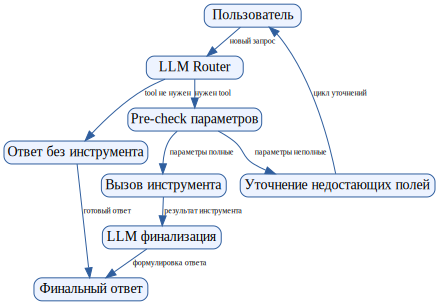

[ИНФО] Граф успешно отрисован через Graphviz.

[ИНФО] Последние строки лога агента:
------------------------------------------------------------------------------------------
[2026-02-17 09:25:17]
ПОЛЬЗОВАТЕЛЬ: Мощность 140 л.с., возраст 29, стаж 7 лет, регион Москва, стоимость авто 2200000, год выпуска 2019, ДТП за 3 года: 1, пробег 18000, доп водителей 1, охраняемая парковка: да, телематика: нет, франшиза: да.
ВЫЗОВ_ИНСТРУМЕНТА_1: calculate_osago_quote
АРГУМЕНТЫ_1: {'engine_power_hp': 140, 'driver_age': 29, 'driving_experience_years': 7, 'region': 'Москва', 'vehicle_market_value': 2200000, 'vehicle_year': 2019, 'accidents_last_3y': 1, 'yearly_mileage_km': 18000, 'additional_drivers_count': 1, 'has_secured_parking': True, 'has_telematics': False, 'has_deductible': True}
РЕЗУЛЬТАТ_ИНСТРУМЕНТА_1: [ИНСТРУМЕНТ] Ориентировочная стоимость ОСАГО: 7792 RUB в год.
ОТВЕТ_СЫРОЙ: <tool_call>
{"name": "calculate_osago_quote", "arguments": {"engine_power_hp": 140, "driver_age": 29, "driving_experie

In [7]:
# 7) Agent flow graph (vertical + compact)

from IPython.display import display

print("[ИНФО] Строим граф исполнения агента...")

nodes = {
    "user": "Пользователь",
    "llm_router": "LLM Router",
    "direct_answer": "Ответ без инструмента",
    "precheck": "Pre-check параметров",
    "clarify": "Уточнение недостающих полей",
    "tool_call": "Вызов инструмента",
    "llm_finalize": "LLM финализация",
    "final": "Финальный ответ",
}

edges = [
    ("user", "llm_router", "новый запрос"),
    ("llm_router", "direct_answer", "tool не нужен"),
    ("direct_answer", "final", "готовый ответ"),
    ("llm_router", "precheck", "нужен tool"),
    ("precheck", "clarify", "параметры неполные"),
    ("clarify", "user", "цикл уточнений"),
    ("precheck", "tool_call", "параметры полные"),
    ("tool_call", "llm_finalize", "результат инструмента"),
    ("llm_finalize", "final", "формулировка ответа"),
]

rendered = False

try:
    from graphviz import Digraph

    dot = Digraph(comment="Agent Flow", format="svg")
    dot.attr(rankdir="TB", fontsize="10", nodesep="0.2", ranksep="0.28")
    dot.attr("node", shape="box", style="rounded,filled", fillcolor="#EDF3FF", color="#2F5E9E", width="1.35", height="0.32", margin="0.05,0.04")
    dot.attr("edge", color="#2F5E9E", fontsize="8")

    for node_id, label in nodes.items():
        dot.node(node_id, label)

    for src, dst, lbl in edges:
        dot.edge(src, dst, label=lbl)

    display(dot)
    rendered = True
    print("[ИНФО] Граф успешно отрисован через Graphviz.")

except Exception as e:
    print(f"[WARN] Graphviz недоступен ({e}). Переключаемся на NetworkX.")

if not rendered:
    import matplotlib.pyplot as plt
    import networkx as nx

    graph = nx.DiGraph()
    for node_id, label in nodes.items():
        graph.add_node(node_id, label=label)
    for src, dst, lbl in edges:
        graph.add_edge(src, dst, label=lbl)

    positions = {
        "user": (0.0, 6.2),
        "llm_router": (0.0, 4.9),
        "direct_answer": (-2.2, 3.6),
        "precheck": (0.0, 3.6),
        "clarify": (2.2, 2.3),
        "tool_call": (0.0, 2.3),
        "llm_finalize": (0.0, 1.0),
        "final": (0.0, -0.3),
    }

    plt.figure(figsize=(6.8, 9.4))
    nx.draw_networkx_nodes(
        graph,
        positions,
        node_size=2000,
        node_color="#EDF3FF",
        edgecolors="#2F5E9E",
        linewidths=1.25,
    )
    nx.draw_networkx_edges(
        graph,
        positions,
        arrows=True,
        arrowstyle="->",
        arrowsize=12,
        edge_color="#2F5E9E",
        width=1.35,
    )

    node_labels = {n: d["label"] for n, d in graph.nodes(data=True)}
    nx.draw_networkx_labels(graph, positions, labels=node_labels, font_size=8)

    edge_labels = {(u, v): d["label"] for u, v, d in graph.edges(data=True)}
    nx.draw_networkx_edge_labels(graph, positions, edge_labels=edge_labels, font_size=7, rotate=False)

    plt.title("Поток агентной системы (вертикальная схема)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    print("[ИНФО] Граф отрисован через NetworkX fallback.")

print("\n[ИНФО] Последние строки лога агента:")
try:
    with open("chat_trace.log", "r", encoding="utf-8") as f:
        lines = f.readlines()[-30:]
    print("".join(lines))
except Exception as e:
    print(f"[ОШИБКА] Не удалось прочитать chat_trace.log: {e}")

print("\n[ИНФО] Последние строки vLLM лога:")
try:
    with open("vllm_server.log", "r", encoding="utf-8") as f:
        lines = f.readlines()[-30:]
    print("".join(lines))
except Exception as e:
    print(f"[ОШИБКА] Не удалось прочитать vllm_server.log: {e}")